In [113]:
import sys
import os
import warnings
from datetime import datetime, timezone, timedelta
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pytz
import json
from zoneinfo import ZoneInfo
from pandas import Timestamp
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from scipy.stats import norm

current_dir = Path.cwd()
parent_dir = current_dir.parent
sys.path.insert(0, str(parent_dir))
from lib import *

MODEL_PATH=parent_dir / 'models' 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

In [114]:
example_ticker = "KXBTC15M-26MAY040515-15"
lookback_minutes = 10000
series, event_dt = parse_kalshi_15m_event_ticker(example_ticker)
dt_only = get_ticker_datetime(example_ticker)
# crypto_at = datetime(2026,5,5,0,0,tzinfo=ZoneInfo('America/Chicago'))
crypto_at = datetime.now(tz=ZoneInfo('America/Chicago'))
df_api = get_market_data_from_api(series, crypto_at, lookback_minutes)
df_api = df_api.set_index('datetime')
df_api.head()

API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting market candlesticks: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/series/KXBTC15M/markets/KXBTC15M-26MAY070215-15/candlesticks?series_ticker=KXBTC15M&ticker=KXBTC15M-26MAY070215-15&start_ts=1778133300&end_ts=1778134500&period_interval=1&include_latest_before_start=True&limit=1000
API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting market candlesticks: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/series/KXBTC15M/markets/KXBTC15M-26MAY070230-30/candlesticks?series_ticker=KXBTC15M&ticker=KXBTC15M-26MAY070230-30&start_ts=1778134200&end_ts=1778135400&period_interval=1&include_latest_before_start=True&limit=1000
API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting ma

,ticker,floor_strike,volume_fp,open_interest_fp,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar
datetime,,,,,,,,,,,,,,,,,,,,
2026-05-06 18:01:00-05:00,KXBTC15M-26MAY061915-15,81356.84,20828.93,16424.18,0.999,0.999,0.270,0.340,0.000,0.460,0.000,0.330,0.670,0.540,1.000,1.000,0.660,0.001,0.730,0.001
2026-05-06 18:02:00-05:00,KXBTC15M-26MAY061915-15,81356.84,35863.67,41566.09,0.340,0.340,0.098,0.170,0.330,0.330,0.084,0.160,0.840,0.670,0.916,0.670,0.830,0.660,0.902,0.660
2026-05-06 18:03:00-05:00,KXBTC15M-26MAY061915-15,81356.84,22128.24,56874.63,0.170,0.210,0.140,0.140,0.160,0.200,0.110,0.130,0.870,0.800,0.890,0.840,0.860,0.790,0.860,0.830
2026-05-06 18:04:00-05:00,KXBTC15M-26MAY061915-15,81356.84,57256.47,90606.91,0.140,0.180,0.020,0.029,0.130,0.130,0.015,0.022,0.978,0.870,0.985,0.870,0.971,0.820,0.980,0.860
2026-05-06 18:05:00-05:00,KXBTC15M-26MAY061915-15,81356.84,33361.68,110977.46,0.029,0.052,0.016,0.034,0.022,0.038,0.012,0.026,0.974,0.962,0.988,0.978,0.966,0.948,0.984,0.971


In [115]:
df_crypto = get_crypto_past_minutes(series, crypto_at, lookback_minutes)
df_crypto['datetime'] = pd.to_datetime(df_crypto['datetime'])
df_crypto['datetime'] = df_crypto['datetime'].dt.tz_convert('America/Chicago')
df_crypto['datetime'] = df_crypto['datetime'].dt.floor('min')
df_crypto = df_crypto.set_index('datetime')
filter_timestamp = df_crypto[df_crypto.index.minute.isin([0,15,30,45])].index[0]
df_crypto = df_crypto[df_crypto.index >= filter_timestamp]
df_crypto.head()

,open,high,low,close,tick_count
datetime,,,,,
2026-05-03 20:30:00-05:00,78544.30,78544.30,78544.30,78544.30,0
2026-05-03 20:31:00-05:00,78583.26,78583.26,78583.26,78583.26,0
2026-05-03 20:32:00-05:00,78697.17,78697.17,78697.17,78697.17,0
2026-05-03 20:33:00-05:00,78925.09,79005.36,78892.57,79000.85,41
2026-05-03 20:34:00-05:00,78990.53,78990.53,78936.38,78936.38,0


In [116]:
df_merged = df_crypto.join(df_api, how='left')
df_merged = df_merged.dropna()
df_merged.head()

,open,high,low,close,tick_count,ticker,floor_strike,volume_fp,open_interest_fp,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar
datetime,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-06 18:01:00-05:00,81345.79,81346.03,81316.64,81317.48,14,KXBTC15M-26MAY061915-15,81356.84,20828.93,16424.18,0.999,0.999,0.270,0.340,0.00,0.46,0.000,0.330,0.670,0.54,1.000,1.00,0.660,0.001,0.730,0.001
2026-05-06 18:02:00-05:00,81321.74,81321.74,81321.60,81321.60,1,KXBTC15M-26MAY061915-15,81356.84,35863.67,41566.09,0.340,0.340,0.098,0.170,0.33,0.33,0.084,0.160,0.840,0.67,0.916,0.67,0.830,0.660,0.902,0.660
2026-05-06 18:03:00-05:00,81252.38,81252.38,81250.71,81250.71,0,KXBTC15M-26MAY061915-15,81356.84,22128.24,56874.63,0.170,0.210,0.140,0.140,0.16,0.20,0.110,0.130,0.870,0.80,0.890,0.84,0.860,0.790,0.860,0.830
2026-05-06 18:04:00-05:00,81264.23,81264.23,81264.23,81264.23,0,KXBTC15M-26MAY061915-15,81356.84,57256.47,90606.91,0.140,0.180,0.020,0.029,0.13,0.13,0.015,0.022,0.978,0.87,0.985,0.87,0.971,0.820,0.980,0.860
2026-05-06 18:22:00-05:00,81269.69,81269.69,81269.69,81269.69,0,KXBTC15M-26MAY061930-30,81247.85,9389.35,36036.29,0.780,0.810,0.720,0.800,0.77,0.80,0.700,0.780,0.220,0.20,0.300,0.23,0.200,0.190,0.280,0.220


In [117]:
df_calc = df_merged

In [118]:
df_calc['yes_dist'] = df_calc['close'] - df_calc['floor_strike']
df_calc['log_return'] = np.log(df_calc['close'] / df_calc['close'].shift(1))
df_calc['m3_log_return'] = df_calc['log_return'].rolling(3).std()
df_calc['m5_log_return'] = df_calc['log_return'].rolling(5).std()
df_calc['ma3'] = df_calc['close'].rolling(3).mean()
df_calc['ma5'] = df_calc['close'].rolling(5).mean()
df_calc['ma3_vs_strike'] = (df_calc['ma3'] - df_calc['floor_strike'])/df_calc['floor_strike'] * 100
df_calc['ma5_vs_strike'] = (df_calc['ma5'] - df_calc['floor_strike'])/df_calc['floor_strike'] * 100
df_calc['yes_dist_pct'] = df_calc['yes_dist'] / df_calc['floor_strike'] * 100
df_calc['m1_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(1)
df_calc['m3_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(3)
df_calc['m5_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(5)
df_calc['time_decay'] = np.where(df_calc.index.minute % 15 == 0, 0, 15 - df_calc.index.minute % 15)
df_calc['hour'] = df_calc.index.hour
df_calc['minute'] = df_calc.index.minute
df_calc['yes_spread'] = df_calc['yes_ask_close_dollar'] - df_calc['yes_bid_close_dollar']
df_calc['volume_surge'] = df_calc['volume_fp'] / df_calc['volume_fp'].rolling(5).mean()
df_calc['oi_change'] = df_calc['open_interest_fp'] - df_calc['open_interest_fp'].shift(1)

In [119]:
df_calc = df_calc.dropna()

In [120]:
df_calc.head()

,open,high,low,close,tick_count,ticker,floor_strike,volume_fp,open_interest_fp,yes_ask_open_dollar,yes_ask_high_dollar,yes_ask_low_dollar,yes_ask_close_dollar,yes_bid_open_dollar,yes_bid_high_dollar,yes_bid_low_dollar,yes_bid_close_dollar,no_ask_open_dollar,no_ask_high_dollar,no_ask_low_dollar,no_ask_close_dollar,no_bid_open_dollar,no_bid_high_dollar,no_bid_low_dollar,no_bid_close_dollar,yes_dist,log_return,m3_log_return,m5_log_return,ma3,ma5,ma3_vs_strike,ma5_vs_strike,yes_dist_pct,m1_yes_dist_momentum,m3_yes_dist_momentum,m5_yes_dist_momentum,time_decay,hour,minute,yes_spread,volume_surge,oi_change
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-06 18:23:00-05:00,81300.79,81300.79,81300.79,81300.79,0,KXBTC15M-26MAY061930-30,81247.85,16795.41,42601.20,0.80,0.921,0.80,0.919,0.78,0.913,0.78,0.913,0.087,0.087,0.22,0.22,0.081,0.079,0.20,0.20,52.94,0.000383,0.000161,0.000483,81278.236667,81281.404,0.037400,0.041298,0.065159,31.10,159.07,92.30,7,18,23,0.006,0.593758,6564.91
2026-05-07 04:01:00-05:00,81225.27,81228.17,81176.07,81176.26,51,KXBTC15M-26MAY070515-15,81214.91,10915.22,7509.56,1.00,1.000,0.29,0.310,0.16,0.580,0.16,0.300,0.700,0.420,0.84,0.84,0.690,0.000,0.71,0.00,-38.65,-0.001533,0.001027,0.000814,81248.913333,81252.336,0.041868,0.046083,-0.047590,-91.59,53.96,-3.41,14,4,1,0.010,0.468526,-35091.64
2026-05-07 04:02:00-05:00,81169.75,81215.00,81169.75,81215.00,39,KXBTC15M-26MAY070515-15,81214.91,12080.51,15607.31,0.31,0.490,0.31,0.360,0.30,0.480,0.29,0.350,0.650,0.520,0.71,0.70,0.640,0.510,0.69,0.69,0.09,0.000477,0.001134,0.000824,81230.683333,81245.194,0.019422,0.037289,0.000111,38.74,-21.75,106.22,13,4,2,0.010,0.567496,8097.75
2026-05-07 04:03:00-05:00,81188.95,81194.75,81141.99,81147.99,48,KXBTC15M-26MAY070515-15,81214.91,5139.09,17235.47,0.36,0.390,0.19,0.190,0.35,0.370,0.17,0.170,0.830,0.630,0.83,0.65,0.810,0.610,0.81,0.64,-66.92,-0.000825,0.001020,0.000866,81179.750000,81221.946,-0.043293,0.008663,-0.082399,-67.01,-119.86,25.69,12,4,3,0.020,0.473042,1628.16
2026-05-07 04:04:00-05:00,81154.13,81154.54,81154.13,81154.54,0,KXBTC15M-26MAY070515-15,81214.91,4309.54,19905.91,0.19,0.190,0.14,0.140,0.17,0.180,0.13,0.130,0.870,0.820,0.87,0.83,0.860,0.810,0.86,0.81,-60.37,0.000081,0.000668,0.000867,81172.510000,81198.916,-0.052207,-0.019693,-0.074334,6.55,-21.72,-82.21,11,4,4,0.010,0.437608,2670.44


In [121]:
def agg_data_function(df, column, *data_cents):
    results = {cent: [] for cent in data_cents}
    triggered = set() 
    
    for i in range(len(df)):
        row = df.iloc[i]
        
        if row['time_decay'] == 0:
            continue
        
        current_ticker = row['ticker']
        
        for cent in data_cents:
            if (current_ticker, cent) in triggered:
                continue
                
            if float(row[column + '_ask_low_dollar']) < float(cent):
                triggered.add((current_ticker, cent)) 
                
                high_price = 0
                low_price = 1
                
                for j in range(1, 16):
                    if i + j >= len(df):
                        break
                    next_row = df.iloc[i + j]
                    high_price = max(next_row[column + '_bid_high_dollar'], high_price)
                    low_price = min(next_row[column + '_bid_high_dollar'], low_price)
                    if next_row['ticker'] != current_ticker or next_row['time_decay'] == 0:
                        break
                
                tmp_dict = row.to_dict()
                tmp_dict['subsequent_high'] = high_price
                tmp_dict['subsequent_low'] = low_price
                tmp_dict['reached_30'] = 1 if high_price >= 0.30 else 0
                tmp_dict['reached_40'] = 1 if high_price >= 0.40 else 0
                tmp_dict['reached_50'] = 1 if high_price >= 0.50 else 0
                tmp_dict['reached_60'] = 1 if high_price >= 0.60 else 0
                tmp_dict['reached_70'] = 1 if high_price >= 0.7 else 0
                tmp_dict['reached_90'] = 1 if high_price >= 0.9 else 0
                results[cent].append(tmp_dict)
    
    return results

In [128]:
res=agg_data_function(df_calc, 'yes', *[0.05,0.1,0.15,0.2,0.25,0.3,0.35])

In [129]:
# win rate analysis
comb_05 = pd.DataFrame(res[0.05])
comb_10 = pd.DataFrame(res[0.10])
comb_15 = pd.DataFrame(res[0.15])
comb_20 = pd.DataFrame(res[0.2])
comb_25 = pd.DataFrame(res[0.25])
comb_30 = pd.DataFrame(res[0.3])
comb_35 = pd.DataFrame(res[0.35])

In [130]:
def get_protential_pnl(df, entry_price, *exit_price):
    for price in exit_price:
        col_name = f"reached_{int(price * 100)}"
        if col_name in df.columns:
            rate = (df[col_name] == 1).sum() / len(df)
            pnl = rate * (float(price) - float(entry_price))
            print(f"Entry: {entry_price}, Exit: {price}, win rate: {rate:.2%}, PNL: {pnl:.4f}")

In [131]:
def evaluate_feature(good_mean, good_std, bad_mean, bad_std):
    diff = good_mean - bad_mean
    avg_std = (good_std + bad_std) / 2
    
    if avg_std < 1e-10:
        return None
    
    ratio = abs(diff) / avg_std
    
    if ratio > 0.5:
        grade = 'strong'
    elif ratio > 0.3:
        grade = 'medium'
    elif ratio > 0.15:
        grade = 'weak'
    else:
        grade = 'useless'
    
    return ratio, grade

In [133]:
get_protential_pnl(comb_05,0.05,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_10,0.10,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_15,0.15,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_20,0.20,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_25,0.25,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_30,0.30,*[0.4,0.5,0.6,0.7,0.9])
get_protential_pnl(comb_35,0.35,*[0.4,0.5,0.6,0.7,0.9])

Entry: 0.05, Exit: 0.4, win rate: 13.25%, PNL: 0.0464
Entry: 0.05, Exit: 0.5, win rate: 13.25%, PNL: 0.0596
Entry: 0.05, Exit: 0.6, win rate: 10.24%, PNL: 0.0563
Entry: 0.05, Exit: 0.7, win rate: 8.43%, PNL: 0.0548
Entry: 0.05, Exit: 0.9, win rate: 4.22%, PNL: 0.0358
Entry: 0.1, Exit: 0.4, win rate: 22.70%, PNL: 0.0681
Entry: 0.1, Exit: 0.5, win rate: 21.08%, PNL: 0.0843
Entry: 0.1, Exit: 0.6, win rate: 16.76%, PNL: 0.0838
Entry: 0.1, Exit: 0.7, win rate: 14.59%, PNL: 0.0876
Entry: 0.1, Exit: 0.9, win rate: 9.73%, PNL: 0.0778
Entry: 0.15, Exit: 0.4, win rate: 33.99%, PNL: 0.0850
Entry: 0.15, Exit: 0.5, win rate: 30.54%, PNL: 0.1069
Entry: 0.15, Exit: 0.6, win rate: 25.62%, PNL: 0.1153
Entry: 0.15, Exit: 0.7, win rate: 21.67%, PNL: 0.1192
Entry: 0.15, Exit: 0.9, win rate: 16.75%, PNL: 0.1256
Entry: 0.2, Exit: 0.4, win rate: 41.74%, PNL: 0.0835
Entry: 0.2, Exit: 0.5, win rate: 37.16%, PNL: 0.1115
Entry: 0.2, Exit: 0.6, win rate: 31.65%, PNL: 0.1266
Entry: 0.2, Exit: 0.7, win rate: 27.52%

In [135]:
feature_cols = [     
    'yes_dist',         
    'log_return',  
    'm3_log_return',
    'm5_log_return',  
    'ma3_vs_strike',
    'ma5_vs_strike',            
    'yes_dist_pct',
    'm1_yes_dist_momentum',
    'm3_yes_dist_momentum',
    'm5_yes_dist_momentum',
    'time_decay',
    'hour',
    'minute',
    'yes_spread',
    'volume_surge',
    'oi_change',
]

comb_list = [0.05, 0.1, 0.15, 0.2, 0.25,0.3,0.35]
reached_list = ['reached_30','reached_40', 'reached_50', 'reached_60', 'reached_70', 'reached_90']

for comb in comb_list: 
    for reached in reached_list:
        df_results = pd.DataFrame(res[comb])
        df_expected = df_results[reached]
        
        # Separate good and bad outcomes
        good = df_results[df_expected == 1]
        bad = df_results[df_expected == 0]
        
        # Prior probabilities
        prior_good = len(good) / len(df_results)
        prior_bad = len(bad) / len(df_results)
        print(f"Comb is {comb}, reached is {reached}")
        print(f"Prior P(Good) = {prior_good:.4f}, P(Bad) = {prior_bad:.4f}")
        likelihoods = {}
        good_ratio_count = 0
        for col in feature_cols:
            good_mean, good_std = good[col].mean(), good[col].std()
            bad_mean, bad_std = bad[col].mean(), bad[col].std()
            
            likelihoods[col] = {
                'good': (good_mean, good_std),
                'bad': (bad_mean, bad_std),
            }
            
            diff = good_mean - bad_mean
            ratio, grade = evaluate_feature(good_mean, good_std, bad_mean, bad_std)
            if grade == 'strong':
                good_ratio_count += 1
            print(f"{grade} -> {col}: Good={good_mean:.4f}, Bad={bad_mean:.4f}, Diff={diff:.4f}")
        print(f"Total Good Ratio is {good_ratio_count}\n")

Comb is 0.05, reached is reached_30
Prior P(Good) = 0.1386, P(Bad) = 0.8614
useless -> yes_dist: Good=-66.9830, Bad=-68.8525, Diff=1.8695
medium -> log_return: Good=0.0001, Bad=-0.0002, Diff=0.0003
weak -> m3_log_return: Good=0.0004, Bad=0.0003, Diff=0.0001
weak -> m5_log_return: Good=0.0004, Bad=0.0003, Diff=0.0001
weak -> ma3_vs_strike: Good=-0.0805, Bad=-0.0670, Diff=-0.0135
weak -> ma5_vs_strike: Good=-0.0684, Bad=-0.0552, Diff=-0.0132
useless -> yes_dist_pct: Good=-0.0830, Bad=-0.0855, Diff=0.0025
useless -> m1_yes_dist_momentum: Good=-14.2517, Bad=-17.2829, Diff=3.0311
useless -> m3_yes_dist_momentum: Good=-37.6496, Bad=-34.5516, Diff=-3.0980
useless -> m5_yes_dist_momentum: Good=-47.5761, Bad=-52.3877, Diff=4.8116
useless -> time_decay: Good=4.3043, Bad=3.9510, Diff=0.3533
weak -> hour: Good=9.3043, Bad=8.4196, Diff=0.8848
useless -> minute: Good=32.8696, Bad=34.1259, Diff=-1.2563
medium -> yes_spread: Good=0.0451, Bad=0.0052, Diff=0.0400
weak -> volume_surge: Good=1.2943, Bad=1

In [136]:
df_results = pd.DataFrame(res[0.15])
df_expected = df_results['reached_50']

# Separate good and bad outcomes
good = df_results[df_expected == 1]
bad = df_results[df_expected == 0]

# Prior probabilities
prior_good = len(good) / len(df_results)
prior_bad = len(bad) / len(df_results)
likelihoods = {}

for col in feature_cols:
    good_mean, good_std = good[col].mean(), good[col].std()
    bad_mean, bad_std = bad[col].mean(), bad[col].std()
    
    likelihoods[col] = {
        'good': (good_mean, good_std),
        'bad': (bad_mean, bad_std),
    }
    
    diff = good_mean - bad_mean
    ratio, grade = evaluate_feature(good_mean, good_std, bad_mean, bad_std)
    if grade == 'strong':
        print(f"{grade} -> {col}: Good={good_mean:.4f}, Bad={bad_mean:.4f}, Diff={diff:.4f}")
params = {}
for col in feature_cols:
    g_mean, g_std = likelihoods[col]['good']
    b_mean, b_std = likelihoods[col]['bad']
    params[col] = {
        'good': (g_mean, g_std),
        'bad': (b_mean, b_std)
    }
    
params['period'] = {
    'good': (prior_good,),
    'bad': (prior_bad,)
}
print(f"good is: {prior_good}, bad is: {prior_bad}")

good is: 0.3054187192118227, bad is: 0.6945812807881774


In [137]:
# type 1 and 2 errors

type1 = 0 
type2 = 0  

total_good = 0
total_bad = 0

good_hours = [6,9]
df_results_hours = df_results[df_results['hour'].isin(good_hours)]


# params = {
#     'period': {
#         'good': (prior_good,),
#         'bad': (prior_bad,)
#     },
#     'yes_dist': {
#         'good': (-33.9818, 38.8993),
#         'bad':  (-60.1364, 53.5074)
#     },
    
#     '1m_yes_dist_momentum': {
#         'good': (-9.8082, 31.6689),
#         'bad':  (-21.8717, 37.5056)
#     },
#     '3m_yes_dist_momentum': {
#         'good': (-12.5696, 72.3349),
#         'bad':  (-39.4029, 54.4311)
#     },
#     '5m_yes_dist_momentum': {
#         'good': (-20.5643, 54.0467),
#         'bad':  (-54.8108, 65.3757)
#     },
#     'time_decay': {
#         'good': (6.0000, 3.5694),
#         'bad':  (5.3866, 2.9375)
#     },
# }

def predict(yes_dist, log_return, m3_log_return, m5_log_return,
            ma3_vs_strike, ma5_vs_strike, yes_dist_pct, m1_yes_dist_momentum,
            m3_yes_dist_momentum, m5_yes_dist_momentum, time_decay, hour, minute):
    # Start from prior odds
    log_odds = np.log(params['period']['good'][0] / params['period']['bad'][0])
    
    feature_values = {
        'yes_dist': yes_dist,
        # 'm3_log_return': m3_log_return,
        # 'm5_log_return': m5_log_return,
        # 'ma3_vs_strike': ma3_vs_strike,
        # 'ma5_vs_strike': ma5_vs_strike,
        'yes_dist_pct': yes_dist_pct,
        'time_decay': time_decay,
        # 'time_decay': time_decay
    }
    
    for name, x in feature_values.items():
        g_m, g_s = params[name]['good']
        b_m, b_s = params[name]['bad']
        
        # Likelihood ratio
        p_g = norm.pdf(x, g_m, g_s + 1e-10)
        p_b = norm.pdf(x, b_m, b_s + 1e-10)
        
        if p_b > 0:
            log_odds += np.log(p_g / p_b)
    
    prob = 1 / (1 + np.exp(-log_odds))
    return prob

for threshold in [0.15, 0.2, 0.25, 0.30, 0.35, 0.40, 0.45]:
    type1, type2 = 0, 0
    total_good, total_bad = 0, 0
    
    for index, row in df_results_hours.iterrows(): 
        p = predict(
            yes_dist = row['yes_dist'],
            log_return = row['log_return'],
            m3_log_return = row['m3_log_return'],
            m5_log_return = row['m5_log_return'],
            ma3_vs_strike = row['ma3_vs_strike'],
            ma5_vs_strike = row['ma5_vs_strike'],
            yes_dist_pct = row['yes_dist_pct'],
            m1_yes_dist_momentum = row['m1_yes_dist_momentum'],
            m3_yes_dist_momentum = row['m3_yes_dist_momentum'],
            m5_yes_dist_momentum = row['m5_yes_dist_momentum'],
            time_decay = row['time_decay'],
            hour = row['hour'],
            minute = row['minute'],
        )
        
        actual = row['reached_40']
        
        if actual == 1:
            total_good += 1
            if p < threshold:
                type1 += 1
        if actual == 0:
            total_bad += 1
            if p >= threshold:
                type2 += 1
    
    bought_good = total_good - type1
    bought_bad = type2
    
    print(f"Threshold={threshold:.2f}: Type1={float(type1/total_good):.2f}, Type2={float(type2/total_bad):.2f}")

Threshold=0.15: Type1=0.00, Type2=1.00
Threshold=0.20: Type1=0.00, Type2=0.94
Threshold=0.25: Type1=0.20, Type2=0.62
Threshold=0.30: Type1=0.47, Type2=0.38
Threshold=0.35: Type1=0.53, Type2=0.31
Threshold=0.40: Type1=0.67, Type2=0.25
Threshold=0.45: Type1=0.73, Type2=0.12


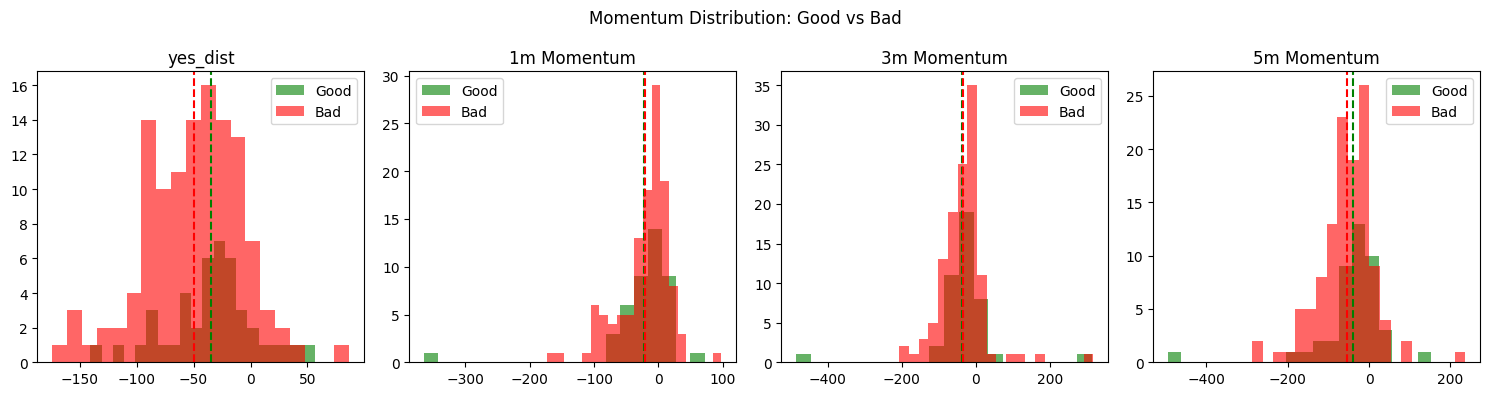

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# good = comb_15[comb_15['reached_70'] == 1]
# bad = comb_15[comb_15['reached_70'] == 0]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# yes_dist
axes[0].hist(good['yes_dist'], bins=20, alpha=0.6, label='Good', color='green')
axes[0].hist(bad['yes_dist'], bins=20, alpha=0.6, label='Bad', color='red')
axes[0].axvline(good['yes_dist'].mean(), color='green', linestyle='--')
axes[0].axvline(bad['yes_dist'].mean(), color='red', linestyle='--')
axes[0].set_title('yes_dist')
axes[0].legend()

# 1m momentum
axes[1].hist(good['1m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[1].hist(bad['1m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[1].axvline(good['1m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[1].axvline(bad['1m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[1].set_title('1m Momentum')
axes[1].legend()

# 3m momentum
axes[2].hist(good['3m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[2].hist(bad['3m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[2].axvline(good['3m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[2].axvline(bad['3m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[2].set_title('3m Momentum')
axes[2].legend()

# 5m momentum
axes[3].hist(good['5m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[3].hist(bad['5m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[3].axvline(good['5m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[3].axvline(bad['5m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[3].set_title('5m Momentum')
axes[3].legend()

plt.suptitle('Momentum Distribution: Good vs Bad')
plt.tight_layout()
plt.show()

In [21]:
# testing

from scipy.stats import norm
import numpy as np

# ===== 1. Extract parameters from your data =====

params = {
    'period': {
        'good': (0.4138,),
        'bad': (0.5862,)
    },
    '1m_yes_dist_momentum': {
        'good': (-17.5070, 51.8947),
        'bad':  (-19.7738, 48.4898)
    },
    '3m_yes_dist_momentum': {
        'good': (-29.0380, 82.5982),
        'bad':  (-32.8337, 73.5574)
    },
    '5m_yes_dist_momentum': {
        'good': (-31.1500, 93.6206),
        'bad':  (-37.5775, 85.6289)
    },
    'yes_dist': {
        'good': (-19.9004, 29.5222),
        'bad':  (-22.8592, 38.3313)
    },
}


# ===== 2. Prediction function =====
def predict(momentum_1m, momentum_3m, momentum_5m, yes_dist):
    # Start from prior odds
    log_odds = np.log(params['period']['good'][0] / params['period']['bad'][0])
    
    feature_values = {
        '1m_yes_dist_momentum': momentum_1m,
        '3m_yes_dist_momentum': momentum_3m,
        # '5m_yes_dist_momentum': momentum_5m,
        'yes_dist': yes_dist
    }
    
    for name, x in feature_values.items():
        g_m, g_s = params[name]['good']
        b_m, b_s = params[name]['bad']
        
        # Likelihood ratio
        p_g = norm.pdf(x, g_m, g_s + 1e-10)
        p_b = norm.pdf(x, b_m, b_s + 1e-10)
        
        if p_b > 0:
            log_odds += np.log(p_g / p_b)
    
    prob = 1 / (1 + np.exp(-log_odds))
    return prob


# ===== 3. Test cases ====

p1 = predict(
    momentum_1m = -26.09,    
    momentum_3m = -88.07,     
    momentum_5m = 0,    
    yes_dist = -39.74      
)
print(f"P(Good): {p1:.1%}")

P(Good): 18.0%


In [30]:
# export model

def write_model_to_json(parameters: dict, filepath: str = None):
    if filepath is None:
        filepath = MODEL_PATH / 'yes_bayesian.json'
    
    params_serializable = {}
    for feature, values in parameters.items():
        params_serializable[feature] = {
            'good': list(values['good']),
            'bad': list(values['bad'])
        }
    
    with open(filepath, 'w') as f:
        json.dump(params_serializable, f, indent=2)
    
    print(f"Model saved to {filepath}")


def load_model_from_json(filepath: str = None):
    if filepath is None:
        filepath = MODEL_PATH / 'yes_bayesian.json'
    
    with open(filepath, 'r') as f:
        params_serializable = json.load(f)
    
    # Convert lists back to tuples
    parameters = {}
    for feature, values in params_serializable.items():
        parameters[feature] = {
            'good': tuple(values['good']),
            'bad': tuple(values['bad'])
        }
    
    return parameters


# Correct dict syntax
params = {
    'period': {
        'good': (0.4138,),
        'bad': (0.5862,)
    },
    '1m_yes_dist_momentum': {
        'good': (-17.5070, 51.8947),
        'bad':  (-19.7738, 48.4898)
    },
    '3m_yes_dist_momentum': {
        'good': (-29.0380, 82.5982),
        'bad':  (-32.8337, 73.5574)
    },
    '5m_yes_dist_momentum': {
        'good': (-31.1500, 93.6206),
        'bad':  (-37.5775, 85.6289)
    },
    'yes_dist': {
        'good': (-19.9004, 29.5222),
        'bad':  (-22.8592, 38.3313)
    },
}



# Write
write_model_to_json(params)

# Read back
loaded = load_model_from_json()
print(loaded['3m_yes_dist_momentum']['good'])  # (-104.941, 95.989)

Model saved to /Users/yingxie/Documents/Git/Quant/Kalshi/btc_15_strategy/models/yes_bayesian.json
(-29.038, 82.5982)


In [138]:
# hour research
reached_list = [50,60,70,90]
time_dict = {str(x): 0 for x in range(24)}
test_df = comb_10
test_entry_price = 10

for hour in range(24):
    for reached in reached_list:
        df_h = test_df[test_df['hour'] == hour]
        if len(df_h) < 5:
            continue
        rate = df_h['reached_' + str(reached)].mean()
        ev = rate * ((reached - test_entry_price) / 100)  - (1-rate) * test_entry_price / 100
        time_dict[str(hour)] += ev

time_dict.sort(lambda x
for key, item in time_dict.items():
    print(f"Hour: {key}, EV: {item:.3f}")

Hour: 0, EV: 0.000
Hour: 1, EV: 0.000
Hour: 2, EV: -0.154
Hour: 3, EV: -0.200
Hour: 4, EV: -0.220
Hour: 5, EV: -0.239
Hour: 6, EV: 0.860
Hour: 7, EV: 0.265
Hour: 8, EV: -0.135
Hour: 9, EV: 0.273
Hour: 10, EV: -0.080
Hour: 11, EV: -0.400
Hour: 12, EV: 0.000
Hour: 13, EV: 0.058
Hour: 14, EV: -0.080
Hour: 15, EV: -0.155
Hour: 16, EV: -0.200
Hour: 17, EV: 0.300
Hour: 18, EV: 0.000
Hour: 19, EV: 0.000
Hour: 20, EV: 0.000
Hour: 21, EV: 0.000
Hour: 22, EV: 0.000
Hour: 23, EV: 0.000


In [141]:
# start research
trade_hour = [6,7,8,9,12,13,17]
reached_dict = {str(x): 0 for x in reached_list}
for hour in trade_hour:
    for reached in reached_list:
        df_h = test_df[test_df['hour'] == hour]
        if len(df_h) < 5:
            continue
        rate = df_h['reached_' + str(reached)].mean()
        ev = rate * ((reached - test_entry_price)/100 - 0.1)  - (1-rate) * test_entry_price / 100
        reached_dict[str(reached)] += ev

for key, item in reached_dict.items():
    print(f"Reached: {key}, EV: {item:.3f}")

Reached: 50, EV: 0.181
Reached: 60, EV: 0.264
Reached: 70, EV: 0.322
Reached: 90, EV: 0.229


In [142]:
# final hour research
trade_hour = [6,7,8,9,12,13,17]
for hour in trade_hour:
    df_h = test_df[test_df['hour'] == hour]
    if len(df_h) < 5:
        continue
    rate = df_h['reached_70'].mean()
    ev = rate * (0.7 - 0.1)  - (1-rate) * 0.10
    print(f"{hour:02d}:00 {len(df_h):3d} trades win {rate:.0%} | EV {ev:.2f}")

06:00  10 trades win 50% | EV 0.25
07:00  17 trades win 24% | EV 0.06
08:00  17 trades win 12% | EV -0.02
09:00  15 trades win 27% | EV 0.09
13:00  12 trades win 17% | EV 0.02
17:00   8 trades win 25% | EV 0.07
